In [148]:
from torchvision import datasets, transforms
from torch.utils.data import IterableDataset, DataLoader, random_split, IterableDataset
import PIL

# the data has to be at plankton-classifier/data/Training3_0 for the next line to work

data_dir = '/gpfs/work/machnitz/plankton_dataset/Training3_0/'
new_data_dir = '/gpfs/work/nonnenma/data/plankton_dataset/Training3_0/'

#dataset = datasets.ImageFolder(data_dir) #, transform=transforms.ToTensor())

dataset = Iterable

# create a train-test split with 90% training data and 10% testing data
train_split = int(len(dataset) * 0.9)
test_split = len(dataset) - train_split
train_dataset, test_dataset = random_split(dataset, [train_split, test_split])

batch_size = 32
train_dataloader = DataLoader(train_dataset, shuffle=True, batch_size=batch_size)
test_dataloader = DataLoader(test_dataset, shuffle=False, batch_size=batch_size)

NameError: name 'Iterable' is not defined

In [1]:
from torchvision import datasets, transforms
from torch.utils.data import IterableDataset, DataLoader, random_split, IterableDataset
import PIL


In [32]:
labels = []
shapes = []
for batch in dataset:
    shapes.append(np.array(batch[0]).shape)
    labels.append(batch[1])

In [30]:
import numpy as np
np.histogram(np.array(labels), bins=np.arange(5))

(array([ 461,   97,  228, 1069]), array([0, 1, 2, 3, 4]))

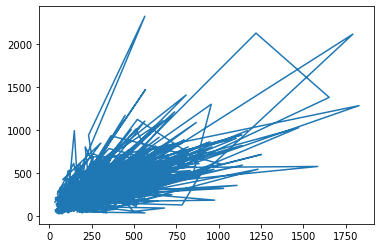

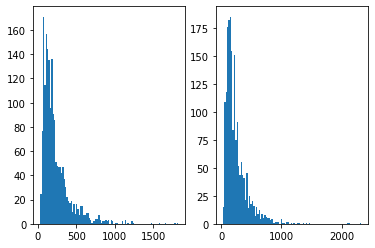

In [41]:
%matplotlib inline
import matplotlib.pyplot as plt

all_shapes = [[i[0] for i in shapes],
              [i[1] for i in shapes],
              [i[2] for i in shapes]]
plt.plot(all_shapes[0], all_shapes[1])
plt.show()

plt.subplot(1,2,1)
plt.hist(all_shapes[0], bins=100)
plt.subplot(1,2,2)
plt.hist(all_shapes[1], bins=100)
plt.show()

In [72]:
import matplotlib
matplotlib.rc('xtick', labelsize=20) 


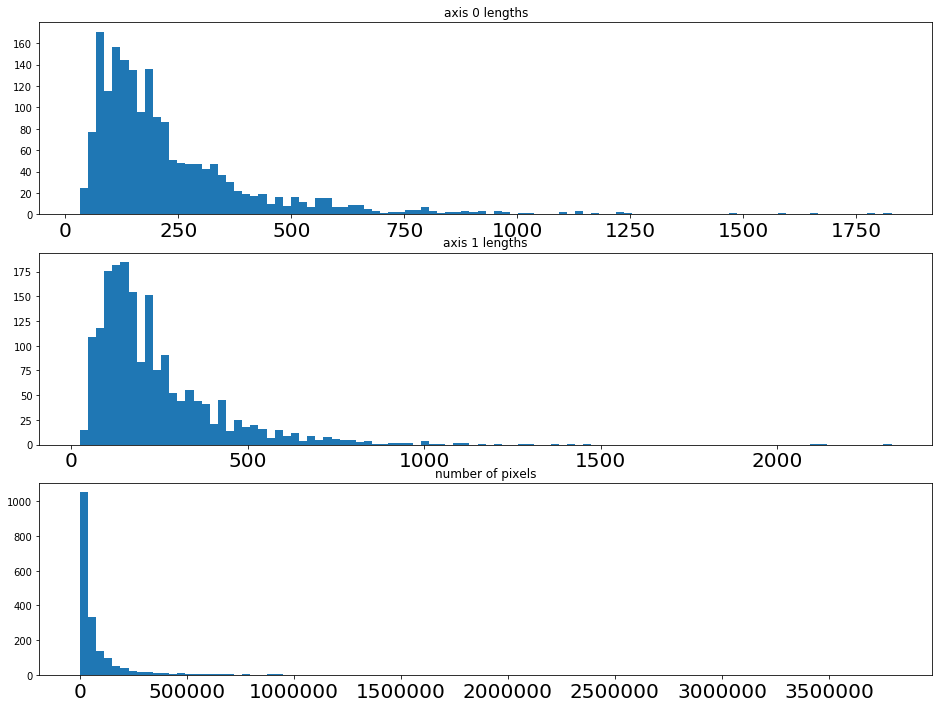

In [75]:
plt.figure(figsize=(16,12))
plt.subplot(3,1,1)
plt.hist(all_shapes[0], bins=100)
plt.title('axis 0 lengths')
plt.subplot(3,1,2)
plt.hist(all_shapes[1], bins=100)
plt.title('axis 1 lengths')
plt.subplot(3,1,3)
plt.hist(np.array(all_shapes[0])*np.array(all_shapes[1]), bins=100)
plt.title('number of pixels')

plt.show()

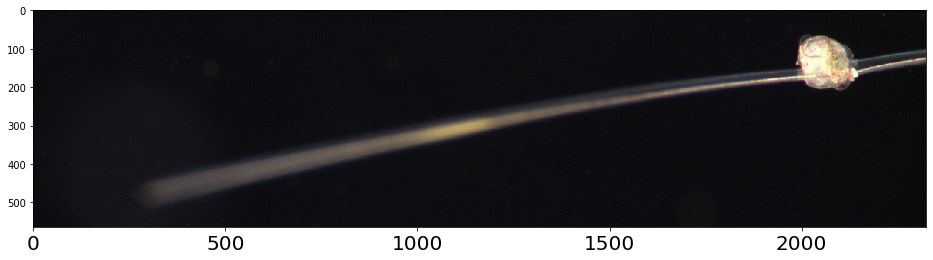

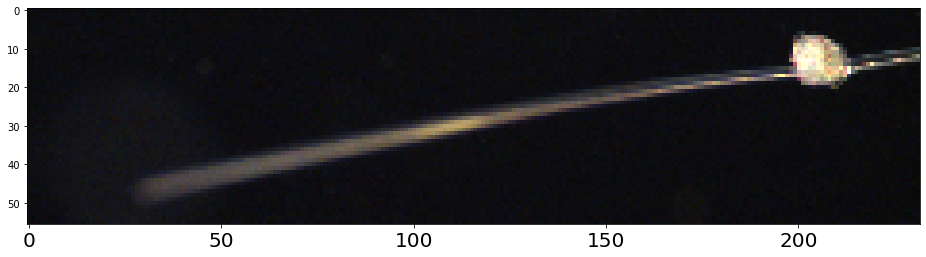

In [81]:
idx = np.argsort(all_shapes[0])[-1]
idx = np.argsort(all_shapes[1])[-1]

plt.figure(figsize=(16,16))
plt.imshow(dataset[idx][0])
plt.show()

plt.figure(figsize=(16,16))
plt.imshow(PIL.ImageOps.scale(dataset[idx][0], factor=0.1))
plt.show()


In [130]:
len(new_imgs)

1855

In [131]:
final_img_size = 64

dtype_np = np.float32

dataset = datasets.ImageFolder(data_dir) #, transform=transforms.ToTensor())

labels = [dataset[i][1] for i in range(len(dataset))]
idx = np.argsort(labels)

new_imgs = np.nan * np.ones((len(dataset), final_img_size, final_img_size, 3), dtype=dtype_np)
masks = np.zeros((len(dataset), final_img_size, final_img_size), dtype=dtype_np)
labels = np.nan * np.ones((len(dataset)))

for i in idx:

    print(i)
    new_img = PIL.ImageOps.pad(dataset[i][0], size=(final_img_size, final_img_size))
    new_img = np.asarray(np.array(new_img)/255, dtype=dtype_np)
    new_imgs[i] = new_img
    masks[i] = np.invert(np.sum(new_img**2,axis=2) == 0)
    labels[i] = dataset[i][1]


0
314
313
312
311
310
309
308
307
306
305
304
315
303
301
300
299
298
297
296
295
294
293
292
291
302
316
317
318
344
343
342
341
340
339
338
337
336
334
333
332
331
330
329
328
327
326
325
324
323
322
321
320
319
290
289
288
287
257
256
255
254
253
252
251
250
249
248
247
246
245
244
243
242
241
240
239
238
237
236
235
234
233
258
345
259
261
286
285
284
283
282
281
280
279
278
277
276
275
274
273
272
271
270
269
268
267
266
265
264
263
262
260
346
347
348
431
430
429
428
427
426
425
424
423
422
421
420
419
418
417
416
415
414
413
412
411
410
409
408
407
432
406
433
435
460
459
458
457
456
455
454
453
452
451
450
449
448
447
446
445
444
443
442
441
440
439
438
437
436
434
232
405
403
373
372
371
370
369
368
367
366
365
364
363
362
361
360
359
358
357
356
355
354
353
352
351
350
349
374
404
375
377
402
401
400
399
398
397
396
395
394
393
392
391
390
389
388
387
386
385
384
383
382
381
380
379
378
376
231
335
229
83
82
81
80
79
78
77
76
75
74
73
72
71
70
69
68
67
66
65
64
63
62
61
60
59

In [5]:
# your code comes here

for batch in train_dataloader:
    print(batch)

TypeError: default_collate: batch must contain tensors, numpy arrays, numbers, dicts or lists; found <class 'PIL.Image.Image'>